# Spike-based Audio Encoding using Rate Coding

This notebook demonstrates how a continuous audio signal can be encoded into spike trains and reconstructed using **rate-based decoding**.

---

## 🎯 Objective

- Generate a synthetic audio waveform
- Encode the waveform into spike trains using **rate coding**
- Reconstruct the signal from spike activity

---

## 🧠 Key Idea

In rate coding, signal amplitude is represented by the **frequency of spikes over time**.

By averaging spike activity, we can recover an approximation of the original signal, showing that spike-based representations can preserve **temporal structure**.

---

## ⚠️ Note

This is a simplified demonstration intended to show how spiking neural systems can represent and process continuous signals like audio.

In [1]:
import torch
import snntorch as snn
from snntorch import surrogate
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
# Generate a synthetic sine wave as toy audio signal

L = 2000
num_steps = 100

t = np.linspace(0, 1, L)
audio = np.sin(2*np.pi*5*t) * 0.5 + 0.5  # normalize to [0,1]

audio = torch.tensor(audio, dtype=torch.float32).unsqueeze(0).to(device)


In [3]:
# Use LIF neuron for rate coding

lif = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())
mem = lif.init_leaky()

spikes = []

for step in range(num_steps):
    spk, mem = lif(audio, mem)
    spikes.append(spk)

spikes = torch.stack(spikes)


In [4]:
# Decode by averaging spike rate over time

recon = spikes.mean(0).squeeze().cpu().numpy()
original = audio.squeeze().cpu().numpy()


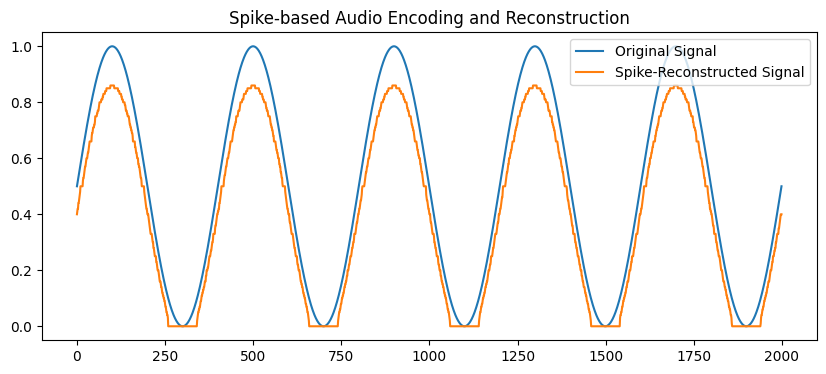

In [5]:
plt.figure(figsize=(10,4))
plt.plot(original, label="Original Signal")
plt.plot(recon, label="Spike-Reconstructed Signal")
plt.legend()
plt.title("Spike-based Audio Encoding and Reconstruction")
plt.show()


## ✅ Conclusion

This notebook demonstrates that spike-based representations can effectively encode and reconstruct continuous signals.

Key observations:
- Rate coding preserves the overall structure of the waveform
- Spike-based decoding recovers frequency and phase information
- SNNs can represent temporal signals like audio

This highlights the potential of spiking neural networks for **signal processing and generative applications**.